In [7]:
#librerie
import numpy as np 
import matplotlib.pyplot as plt
import random

In [8]:
#paarametri della simulazione
NUMERO_TRADER = 200
BETA = 1
NUMERO_BITCOIN = 80000
TOTALE_CASH = 400000

In [9]:
#verifichiamo i parametri
print("Numero di trader:", NUMERO_TRADER)
print("Beta:", BETA)
print("Numero di bitcoin:", NUMERO_BITCOIN)
print("Totale cash:", TOTALE_CASH)

Numero di trader: 200
Beta: 1
Numero di bitcoin: 80000
Totale cash: 400000


In [10]:
#funzione distribuzione di Pareto
def ricchezza_proporzionale_pareto(numero_trader, totale_ricchezza, beta):
    posizione = np.arange(1, numero_trader + 1)
    pesi = 1 / (posizione ** beta)
    pesi_normalizzati = pesi / np.sum(pesi)
    ricchezza = pesi_normalizzati * totale_ricchezza

    return ricchezza

In [11]:
#distribuzione di Bicoin e cash tra i trader
bitcoin_trader = ricchezza_proporzionale_pareto(NUMERO_TRADER, NUMERO_BITCOIN, BETA)
cash_trader = ricchezza_proporzionale_pareto(NUMERO_TRADER, TOTALE_CASH, BETA)

In [12]:
class Trader:
    def __init__(self, id_trader, cash, bitcoin):
        self.id_trader = id_trader
        self.cash = cash
        self.bitcoin = bitcoin

    def genera_ricchezza(self, prezzo_bitcoin):
        return self.cash + self.bitcoin * prezzo_bitcoin

    def __str__(self):
        return (f"Trader #{self.id_trader} | "
                f"Cash: ${self.cash:.2f} | "
                f"Bitcoin: {self.bitcoin:.4f} BTC")

In [13]:
# Funzione per generare la ricchezza secondo distribuzione di Pareto

def ricchezza_proporzionale_pareto(numero_trader, ricchezza_totale, beta):
    """Genera una distribuzione di ricchezza secondo Pareto"""
    # Generiamo numeri casuali da una distribuzione di Pareto
    pareto_values = np.random.pareto(beta, numero_trader)
    # Normalizziamo a sommare a ricchezza_totale
    ricchezza = (pareto_values / pareto_values.sum()) * ricchezza_totale
    return ricchezza

In [14]:
#creiamo i Random Trader

class RandomTrader(Trader):

    PROBABILITA_ESSERE_ATTIVO = 0.10

    def __init__(self, id_trader, cash, bitcoin):
        super().__init__(id_trader, cash, bitcoin)
        self.tipo = "Random"

    def attivita_trader(self):
      return random.random() < self.PROBABILITA_ESSERE_ATTIVO

    def decide_ordine(self, prezzo_corrente):
        if random.random() < 0.5:
            if self.cash > 0:
                return 'compra'
            
        else:
            if self.bitcoin > 0:
                return 'vendi'
            
        return None
    
    def __str__(self):
        return f"[{self.tipo}] " + super().__str__()

In [15]:
class Chartist(Trader):
    PROBABILITA_ESSERE_ATTIVO = 0.50
    SOGLIA = 0.01

    def __init__(self, id_trader, cash, bitcoin, finestra_temporale=20):
        super().__init__(id_trader, cash, bitcoin)
        self.tipo = "Chartist"
        self.finestra = finestra_temporale
        self.prezzo_precedente = None

    def attivita_trader(self):
        return random.random() < self.PROBABILITA_ESSERE_ATTIVO
    
    def variazione_prezzo(self, storico_prezzi):
        if len(storico_prezzi) < 2:
            return 0
       
        prezzo_oggi = storico_prezzi[-1]
        prezzo_passato = storico_prezzi[-2]
        variazione = (prezzo_oggi - prezzo_passato) / prezzo_passato
        return variazione
    
    def decide_ordine(self, prezzo_corrente, storico_prezzi):
        variazione = self.variazione_prezzo(storico_prezzi)

        if variazione > self.SOGLIA and self.cash > 0:
            return 'compra'
        elif variazione < -self.SOGLIA and self.bitcoin > 0:
            return 'vendi'
        
        return None
    
    def __str__(self):
        return f"[{self.tipo} τ={self.finestra}] " + super().__str__()

In [16]:
#creiamo la funzione per generare la popolazione di Trader

def crea_popolazione_trader(numero_trader, bitcoin_totali, cash_trader, probabilita_random=0.70, beta=1):
    bitcoin_assegnati = ricchezza_proporzionale_pareto(numero_trader, bitcoin_totali, beta)
    cash_assegnato = ricchezza_proporzionale_pareto(numero_trader, cash_trader, beta)

    indici = np.arange(numero_trader)
    np.random.shuffle(indici)
    bitcoin_assegnati = bitcoin_assegnati[indici]
    cash_assegnato = cash_assegnato[indici]

    traders = []

    for i in range(numero_trader):
        if random.random() < probabilita_random:
            t = RandomTrader(
                    id_trader = i + 1,
                    cash      = cash_assegnato[i],
                    bitcoin   = bitcoin_assegnati[i]
            )

        else:
            finestra = random.randint(10, 50)
            t = Chartist(
                id_trader         = i + 1,
                cash              = cash_assegnato[i],
                bitcoin           = bitcoin_assegnati[i],
                finestra_temporale = finestra
            )
        
        traders.append(t)   # aggiungiamo il trader alla lista
    
    return traders

In [17]:
#creiamo effettivamente la popolazione di trader

random.seed(42)
np.random.seed(42)

N_TRADER = 100
BITCOIN_TOTALI = 80000
CASH_TOTALE = 400000
PREZZO_INIZIALE = 5.0 

tutti_i_trader = crea_popolazione_trader(N_TRADER, BITCOIN_TOTALI, CASH_TOTALE)

n_random   = sum(1 for t in tutti_i_trader if isinstance(t, RandomTrader))
n_chartist = sum(1 for t in tutti_i_trader if isinstance(t, Chartist))

print(f"✅ Popolazione creata!")
print(f"   Trader totali: {len(tutti_i_trader)}")
print(f"   RandomTrader:  {n_random} ({n_random/N_TRADER:.0%})")
print(f"   Chartist:      {n_chartist} ({n_chartist/N_TRADER:.0%})")

print("\nI primi 5 trader:")
for t in tutti_i_trader[:5]:
    print(" ", t)


✅ Popolazione creata!
   Trader totali: 100
   RandomTrader:  75 (75%)
   Chartist:      25 (25%)

I primi 5 trader:
  [Random] Trader #1 | Cash: $2868.15 | Bitcoin: 235.0651 BTC
  [Random] Trader #2 | Cash: $208.11 | Bitcoin: 6917.9425 BTC
  [Random] Trader #3 | Cash: $74369.91 | Bitcoin: 319.1276 BTC
  [Random] Trader #4 | Cash: $341.09 | Bitcoin: 739.8096 BTC
  [Chartist τ=44] Trader #5 | Cash: $364.34 | Bitcoin: 210.5189 BTC


In [18]:
#simuliamo una giornata di trading

storico_prezzi = [5.0] * 40 + [5.1, 5.2, 5.3, 5.4, 5.5]

n_compratori = 0
n_venditori  = 0
n_inattivi   = 0

for trader in tutti_i_trader:
    
    if not trader.attivita_trader():
        n_inattivi += 1
        continue

    if isinstance(trader, RandomTrader):
        ordine = trader.decide_ordine(storico_prezzi[-1])

    else:
        ordine = trader.decide_ordine(storico_prezzi[-1], storico_prezzi)
    
    if ordine == 'compra':
        n_compratori += 1
    elif ordine == 'vendi':
        n_venditori += 1
    else:
        n_inattivi += 1

print(f"   Compratori oggi: {n_compratori}")
print(f"   Venditori oggi:  {n_venditori}")
print(f"   Non attivi:      {n_inattivi}")
print()

if n_compratori > n_venditori:
    print("📈 Più compratori che venditori → il prezzo tenderà a SALIRE")
elif n_venditori > n_compratori:
    print("📉 Più venditori che compratori → il prezzo tenderà a SCENDERE")
else:
    print("➡️  Compratori e venditori bilanciati → il prezzo resterà stabile")

   Compratori oggi: 19
   Venditori oggi:  5
   Non attivi:      76

📈 Più compratori che venditori → il prezzo tenderà a SALIRE


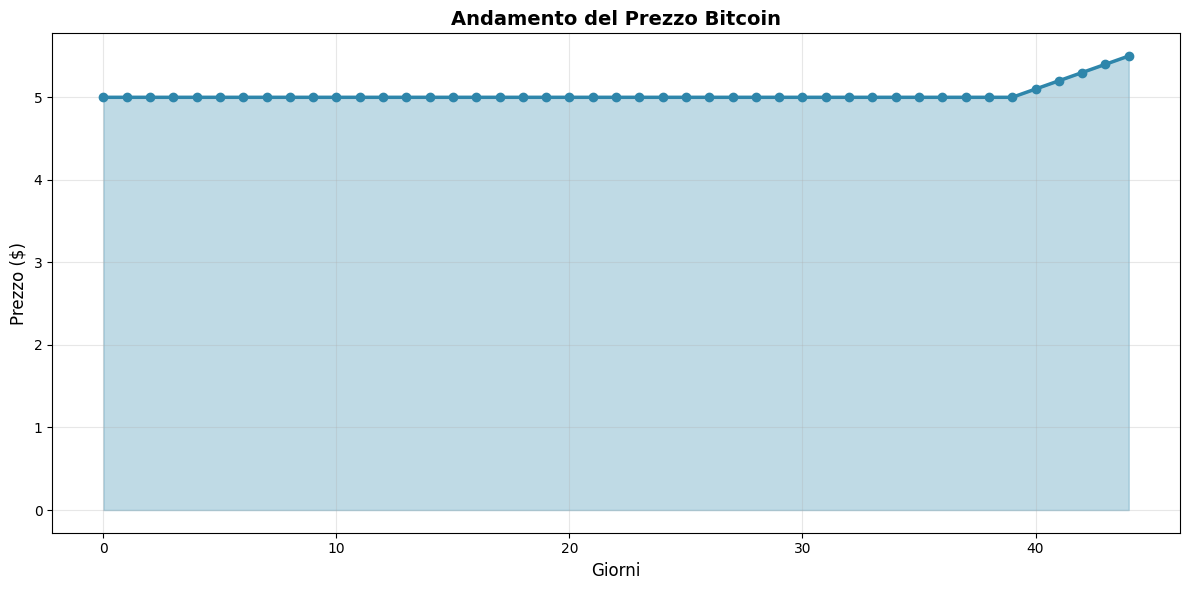

In [19]:
#Grafico del prezzo

plt.figure(figsize=(12, 6))
plt.plot(storico_prezzi, linewidth=2.5, color='#2E86AB', marker='o', markersize=6)
plt.fill_between(range(len(storico_prezzi)), storico_prezzi, alpha=0.3, color='#2E86AB')
plt.title('Andamento del Prezzo Bitcoin', fontsize=14, fontweight='bold')
plt.xlabel('Giorni', fontsize=12)
plt.ylabel('Prezzo ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
class Ordine:
    """Classe base per un ordine di mercato (buy o sell)."""

    _contatore = 0  # contatore di classe → ID univoco globale

    def __init__(self, trader, quantita_bitcoin, prezzo_limite=None):
        Ordine._contatore += 1
        self.id_ordine        = Ordine._contatore
        self.trader           = trader
        self.quantita         = quantita_bitcoin      # BTC totali
        self.quantita_residua = quantita_bitcoin      # BTC ancora da eseguire
        self.prezzo_limite    = prezzo_limite          # None = market order
        self.timestamp        = Ordine._contatore     # proxy temporale

    # ── metodi di stato ──────────────────────────────────
    def e_market_order(self):
        """True se non ha un prezzo limite (market order)."""
        return self.prezzo_limite is None

    def e_eseguito(self):
        """True se la quantità residua è praticamente zero."""
        return self.quantita_residua <= 1e-10

    def __repr__(self):
        tipo = 'MARKET' if self.e_market_order() else f'LIMIT@{self.prezzo_limite:.4f}'
        return (f'Ordine#{self.id_ordine} [{tipo}] '
                f'qty={self.quantita:.4f} '
                f'residuo={self.quantita_residua:.4f} '
                f'trader={self.trader.id_trader}')

print('✅ Classe Ordine definita.')

✅ Classe Ordine definita.


In [21]:
class BuyOrder(Ordine):
    """Ordine di ACQUISTO: il trader vuole comprare BTC pagando con cash."""

    def __init__(self, trader, quantita_bitcoin, prezzo_limite=None):
        super().__init__(trader, quantita_bitcoin, prezzo_limite)

    def compatibile_con(self, sell_order):
        """
        Un buy è compatibile con un sell se:
        - almeno uno dei due è market order, OPPURE
        - il prezzo limite del buy >= prezzo limite del sell
        """
        if self.e_market_order() or sell_order.e_market_order():
            return True
        return self.prezzo_limite >= sell_order.prezzo_limite

    def __repr__(self):
        return 'BUY  ' + super().__repr__()


class SellOrder(Ordine):
    """Ordine di VENDITA: il trader vuole vendere BTC ottenendo cash."""

    def __init__(self, trader, quantita_bitcoin, prezzo_limite=None):
        super().__init__(trader, quantita_bitcoin, prezzo_limite)

    def __repr__(self):
        return 'SELL ' + super().__repr__()


# ── Test rapido ───────────────────────────────────────────────────────────
t1 = RandomTrader(1, cash=1000, bitcoin=5)
t2 = RandomTrader(2, cash=500,  bitcoin=10)

b = BuyOrder(t1,  quantita_bitcoin=1.0, prezzo_limite=5.30)
s = SellOrder(t2, quantita_bitcoin=1.0, prezzo_limite=5.20)

print('BuyOrder  →', b)
print('SellOrder →', s)
print(f'Compatibili? {b.compatibile_con(s)}')
print('✅ BuyOrder e SellOrder funzionanti.')

BuyOrder  → BUY  Ordine#1 [LIMIT@5.3000] qty=1.0000 residuo=1.0000 trader=1
SellOrder → SELL Ordine#2 [LIMIT@5.2000] qty=1.0000 residuo=1.0000 trader=2
Compatibili? True
✅ BuyOrder e SellOrder funzionanti.


In [22]:
class OrderBook:
    """
    Order Book aggregato.
    - Buy  orders: ordinati per prezzo DECRESCENTE (market order prima)
    - Sell orders: ordinati per prezzo CRESCENTE   (market order prima)
    """

    def __init__(self):
        self.buy_orders  = deque()  # testa = priorità maggiore
        self.sell_orders = deque()  # testa = priorità maggiore
        self.transazioni = []       # storico delle transazioni del giorno

    # ── ordinamento ──────────────────────────────────────
    def _priorita_buy(self, o):
        """Market order prima; poi prezzo decrescente; poi FIFO."""
        if o.e_market_order(): return (0, 0, o.timestamp)
        return (1, -o.prezzo_limite, o.timestamp)

    def _priorita_sell(self, o):
        """Market order prima; poi prezzo crescente; poi FIFO."""
        if o.e_market_order(): return (0, 0, o.timestamp)
        return (1, o.prezzo_limite, o.timestamp)

    # ── inserimento ──────────────────────────────────────
    def inserisci_buy(self, ordine: BuyOrder):
        """Inserisce un buy order mantenendo l'ordinamento."""
        lst = list(self.buy_orders)
        lst.append(ordine)
        lst.sort(key=self._priorita_buy)
        self.buy_orders = deque(lst)

    def inserisci_sell(self, ordine: SellOrder):
        """Inserisce un sell order mantenendo l'ordinamento."""
        lst = list(self.sell_orders)
        lst.append(ordine)
        lst.sort(key=self._priorita_sell)
        self.sell_orders = deque(lst)

    # ── matching ─────────────────────────────────────────
    def match(self, prezzo_corrente):
        """
        Esegue il matching tra buy e sell orders.
        Aggiorna i portafogli dei trader e registra le transazioni.

        Ritorna:
            nuovo_prezzo  (float) — prezzo aggiornato dopo il matching
            n_transazioni (int)   — numero di transazioni eseguite
        """
        prezzi_tx  = []
        volumi_tx  = []

        while self.buy_orders and self.sell_orders:
            buy  = self.buy_orders[0]
            sell = self.sell_orders[0]

            # 1. Controlla compatibilità
            if not buy.compatibile_con(sell):
                break  # la testa non si incrocia → stop

            # 2. Prezzo di esecuzione
            prezzo_tx = self._calcola_prezzo_transazione(buy, sell, prezzo_corrente)

            # 3. Quantità scambiata = minimo dei residui
            qty = min(buy.quantita_residua, sell.quantita_residua)

            # 4. Aggiorna portafogli
            costo = qty * prezzo_tx
            buy.trader.cash     -= costo
            buy.trader.bitcoin  += qty
            sell.trader.cash    += costo
            sell.trader.bitcoin -= qty

            # 5. Aggiorna quantità residue
            buy.quantita_residua  -= qty
            sell.quantita_residua -= qty

            # 6. Salva transazione
            self.transazioni.append({
                'prezzo':       prezzo_tx,
                'quantita':     qty,
                'buy_trader':   buy.trader.id_trader,
                'sell_trader':  sell.trader.id_trader,
            })
            prezzi_tx.append(prezzo_tx)
            volumi_tx.append(qty)

            # 7. Rimuovi ordini esauriti
            if buy.e_eseguito():  self.buy_orders.popleft()
            if sell.e_eseguito(): self.sell_orders.popleft()

        # Nuovo prezzo = media ponderata per volume delle transazioni
        if prezzi_tx:
            vol_tot      = sum(volumi_tx)
            nuovo_prezzo = sum(p * v for p, v in zip(prezzi_tx, volumi_tx)) / vol_tot
        else:
            nuovo_prezzo = prezzo_corrente

        return nuovo_prezzo, len(prezzi_tx)

    def _calcola_prezzo_transazione(self, buy, sell, prezzo_corrente):
        """Regole di formazione del prezzo (Cocco et al. 2017, Sezione 3.3)."""
        b_mkt = buy.e_market_order()
        s_mkt = sell.e_market_order()

        if b_mkt and s_mkt:
            return prezzo_corrente
        elif b_mkt:
            return max(sell.prezzo_limite, prezzo_corrente)
        elif s_mkt:
            return min(buy.prezzo_limite, prezzo_corrente)
        else:
            return (buy.prezzo_limite + sell.prezzo_limite) / 2

    def reset_giornaliero(self):
        """Svuota il book e le transazioni per iniziare un nuovo giorno."""
        self.buy_orders  = deque()
        self.sell_orders = deque()
        self.transazioni = []

    def stato(self):
        """Stampa un riepilogo dello stato corrente."""
        print(f'  📗 Buy  orders in attesa: {len(self.buy_orders)}')
        print(f'  📕 Sell orders in attesa: {len(self.sell_orders)}')
        print(f'  ✅ Transazioni eseguite:  {len(self.transazioni)}')

    def __repr__(self):
        return f'OrderBook(buy={len(self.buy_orders)}, sell={len(self.sell_orders)})'


print('✅ Classe OrderBook definita.')

✅ Classe OrderBook definita.
